In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import heapq
import signal

In [8]:
class TreeNode:
    def __init__(self, level, V, W, taken, upper_bound=None):
        self.level = level  # niveau dans l’arbre de recherche >=0
        self.V = V  # valeur de la solution courante
        self.W = W  # poids de la solution courante
        self.taken = taken  # liste des index d’objets de la solution courante
        self.upper_bound = upper_bound  # Upper Bound of the solution (for Best First method)

    def __lt__(self, other):
        return (self.upper_bound or 0) > (other.upper_bound or 0)  # Highest bound has priority
    

class KPBB_BestFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.unordered = [((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))]
        self.ordered = sorted([((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))], key=lambda tup: float(tup[0][0])/tup[0][1], reverse=True)
    
    def UpperBound(self, node): # calcul UpperBound
        W = self.capacity - node.W # remaining capacity
        result = node.V
        i = node.level + 1 # next level
        
        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1]) 
        return result

    def solve(self):
        root = TreeNode(-1, 0, 0, [], self.UpperBound(TreeNode(-1, 0, 0, [], 0)))  # root node
        queue = []
        heapq.heappush(queue, root)

        self.bestValue = 0
        self.bestTaken = []

        self.n_it = 0

        while queue:
            node = heapq.heappop(queue)
            self.n_it = self.n_it + 1

            if node.upper_bound <= self.bestValue:
                continue  # Cuts the node

            if node.level < len(self.ordered) - 1:
                # Caso 1: Incluir o item
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(node.level + 1, node.V + item[0][0], node.W + item[0][1], node.taken + [item[1]], self.UpperBound(node))
                
                if nodeRight.W <= self.capacity and nodeRight.V > self.bestValue:
                    self.bestValue = nodeRight.V
                    self.bestTaken = nodeRight.taken

                if nodeRight.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeRight)

                # Caso 2: Não incluir o item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken, self.UpperBound(node))
                
                if nodeLeft.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeLeft)

        return self.bestValue, self.bestTaken, self.n_it    
    
    
def knapsack_BU(values, weights, W):
    W = int(W) 
    n = len(values) 

    dp = [[0] * (W + 1) for _ in range(n + 1)] # Zero Matrix with (n+1) rows and (W+1) columns 
    n_it = 0

    for i in range(n): # for each item 
        n_it = n_it + 1
        wi = int(weights[i]) 

        for x in range(W + 1):  # Cycle through all possible backpack capacities
            # If you don't get the current item
            dp[i + 1][x] = dp[i][x]

            #  Possibility 2: take the item 
            if wi <= x: # checks if it fits in the backpack
                dp[i + 1][x] = max(dp[i + 1][x], values[i] + dp[i][x - wi])

    # The maximum possible value is in the last cell of the matrix
    return dp[n][W], n_it 

def initial_solution(weights, values, wmax): # generates a inicial solution
    n = len(weights)
    selected = np.zeros(n, dtype=int) # list of selected itens
    W = wmax
    result = 0

    indices = np.random.permutation(n)  # Shuffle ids to have a random start

    for i in indices: # fills the knapsack 
        if W >= weights[i]:
            selected[i] = 1
            W -= weights[i]
            result += values[i]

    return selected, result, W # returns a random start

def knapsack_value(selected, weights, values): # calculates the value and weight of a knapsack
    value = np.dot(selected, values)
    weight = np.dot(selected, weights)
    return value, weight

def get_neighbor(selected, weights, values, wmax):
    """Gera um vizinho trocando múltiplos itens com baixa probabilidade."""
    neighbor = selected.copy()
    n = len(weights)
    
    # Probabilidade de trocar mais de um item em problemas grandes
    num_changes = 1 if n < 50 else np.random.randint(1, min(5, n // 10))  

    for _ in range(num_changes):
        i = np.random.randint(n)
        neighbor[i] = 1 - neighbor[i]  # Alterna 0/1

    new_value, new_weight = knapsack_value(neighbor, weights, values)

    # Se ultrapassar o peso máximo, reverte as mudanças
    if new_weight > wmax:
        neighbor = selected.copy()
        new_value, new_weight = knapsack_value(neighbor, weights, values)

    return neighbor, new_value, new_weight

def simulated_annealing_knapsack(values, weights, wmax, T0=100, coeff=0.99, iter_step=100, stop_threshold=0.001):
    current_solution, current_value, current_weight = initial_solution(weights, values, wmax) # generates random initial solution
    best_solution = current_solution.copy()
    best_value = current_value
    T = T0 # initial temperature
    n_it = 0

    while T > stop_threshold: # while ther is still temperarure
        n_it = n_it +1
        nb_moves = 0
        for i in range(iter_step):
            # Generates a neighbor
            new_solution, new_value, new_weight = get_neighbor(current_solution, weights, values, wmax)
            
            # calculates the delta
            delta = new_value - current_value

            # Metropolis Criteria
            if delta > 0 or np.random.rand() < np.exp(delta / T): # if it is better or is hot enough 
                current_solution = new_solution.copy() # updates the current solution
                current_value = new_value
                current_weight = new_weight
                nb_moves += 1

                # Update the best if necessary
                if current_value > best_value:
                    best_solution = current_solution.copy()
                    best_value = current_value

        # Decreases temperature
        acceptance_rate = nb_moves / iter_step if iter_step > 0 else 0
        if acceptance_rate < stop_threshold:
            break  # Critério de parada se a aceitação for muito baixa
        T *= coeff

    return best_solution, best_value, n_it

## Exercice 1 – Algorithme Génétique pour le problème du sac à dos 0/1
On vous demande dans cet exercice de programmer un algorithme génétique pour résoudre le problème du sac à dos 0/1. Vous testerez votre algorithme sur les données fournies lors des séances précédentes. Vous comparerez statistiquement (donc en faisant de multiples run de votre algorithme, ce qui est indispensable quand l’aléatoire intervient) les résultats de votre algorithme avec ceux obtenus par les méthodes concurrentes. Vous pourrez également analyser l’impact des différents paramètres de l’algorithme.

In [19]:
def fitness(parent, values, weights, W):
    Wp = parent@weights
    if Wp <= W:
        Vp = parent@values
    else:
        Vp = 0
    return Vp

def tournemant(population, Vps):
    new_population = []
    for i in range(0, len(population), 2):
        if Vps[i] >= Vps[i+1]:
            new_population.append(population[i])
        else:
            new_population.append(population[i+1])
    
    return new_population

def childs(population):
    childs = []
    n = len(population)
    j = np.random.randint(len(population[0]))
    for i in range(0, n, 2):
        child1 = np.concatenate((population[i][0:j],population[i+1][j:]))
        child2 = np.concatenate((population[i+1][0:j],population[i][j:]))
        childs.append(child1)
        childs.append(child2)
    return childs

def mutation(population, mutation_rate):
    for child in population:
        if np.random.random() <= mutation_rate:
            j = np.random.randint(len(population[0]))
            child[j] = 1 - child[j]
    return population

def knapsack_genetic(values, weights, W, pop_size=100, generations=5000, mutation_rate=0.01):
    n = len(values)

    population = np.random.randint(2, size=(pop_size, n))
    Vps = np.zeros(pop_size)

    for gen in range(generations):
        it = 0
        for parent in population:
            Vps[it] = fitness(parent, values, weights, W)
            it += 1

        new_population = tournemant(population, Vps)

        population = childs(population)
        population = mutation(population, mutation_rate)

        it = 0
        for parent in population:
            Vps[it] = fitness(parent, values, weights, W)
            it += 1

    bestValue = max(Vps)
    bestTaken = population[np.argmax(Vps)]

    return bestValue, bestTaken

In [4]:
def knapsack_genetic(values, weights, W, pop_size=100, generations=500, mutation_rate=0.01, tournament_size=5):
    num_items = len(values)

    def fitness(individual):
        """Calcula o valor da mochila e penaliza se ultrapassar o peso máximo."""
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else 0  # Penaliza soluções inválidas

    def selection(population):
        """Seleciona um indivíduo pelo método de torneio."""
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2):
        """Crossover de um ponto."""
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual):
        """Aplica mutação bit a bit."""
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]  # Inverte o bit
        return individual

    # Inicialização da população
    population = np.random.randint(2, size=(pop_size, num_items))

    # Evolução da população
    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutation(child)
            new_population.append(child)
        population = np.array(new_population)

    # Escolher a melhor solução final
    best_individual = max(population, key=fitness)
    return fitness(best_individual), best_individual

In [5]:
values = [60, 100, 120]
weights = [10, 20, 30]
W = 50
bestValue, bestTaken = knapsack_genetic(values, weights, W)
print(bestValue)
print(bestTaken)



220
[0 1 1]


### Single Test

In [6]:
path = "./instances_01_KP/low-dimensional/f10_l-d_kp_20_879" 
dataset = np.loadtxt(path)

n = int(dataset[0][0])
wmax = dataset[0][1]
itens = dataset[1:]

weights = dataset[1:,1]
values = dataset[1:,0]

print(weights)
print(values)

[84. 83. 43.  4. 44.  6. 82. 92. 25. 83. 56. 18. 58. 14. 48. 70. 96. 32.
 68. 92.]
[91. 72. 90. 46. 55.  8. 35. 75. 61. 15. 77. 40. 63. 75. 29. 75. 17. 78.
 40. 44.]


In [9]:
methods = {
    "Genetic Algrithm": knapsack_genetic,
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
n_values = []

for method_name, method in methods.items():
    tic = time.perf_counter()

    if method_name == "Genetic Algrithm":
        bestValue, bestTaken = method(values, weights, wmax)  
        n_it = 0
        print("Estimated Best value:", bestValue)
    elif method_name == "Simulated Annealing":
        bestTaken, bestValue, n_it = method(values, weights, wmax)  
        print("Estimated Best value:", bestValue)
    elif method_name == "Bottom-Up":
        bestValue, n_it = method(values, weights, wmax)  
        print("Optimal value:", bestValue)
        bestTaken = None
    else:
        knapsack_solver = method(values, weights, wmax)
        print("Chosen itens:", bestTaken)
        bestValue, bestTaken, n_it = knapsack_solver.solve()

    toc = time.perf_counter()
    times[method_name].append(toc - tic)
    print(f"{method_name} = {(toc - tic):.4}s")
    print(n_it, "iteraions \n")

n_values.append(n)

Estimated Best value: 1025.0
Genetic Algrithm = 4.726s
0 iteraions 

Estimated Best value: 1025.0
Simulated Annealing = 1.315s
1146 iteraions 

Optimal value: 1025.0
Bottom-Up = 0.009044s
20 iteraions 

Chosen itens: None
B&B Best First = 0.0007781s
121 iteraions 



### Low Dimensional

In [23]:
datasets = []
listing = os.listdir("./instances_01_KP/low-dimensional/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    path = "./instances_01_KP/low-dimensional/" + infile
    data = np.loadtxt(path)
    datasets.append(data)


=== Problem with 15 items and 375 capacity ===
Estimated Best value: 328.55616899999995
Genetic Algrithm = 1.917s
0 iteraions 

Estimated Best value: 481.06936799999994
Simulated Annealing = 0.5122s
1146 iteraions 

Optimal value: 481.069368
Bottom-Up = 0.001287s
15 iteraions 

Chosen itens: [11, 7, 10, 6, 2, 4, 14, 13, 9]
B&B Best First = 0.0003417s
157 iteraions 


=== Problem with 10 items and 269 capacity ===
Estimated Best value: 290.0
Genetic Algrithm = 1.861s
0 iteraions 

Estimated Best value: 295.0
Simulated Annealing = 0.5022s
1146 iteraions 

Optimal value: 295.0
Bottom-Up = 0.0006139s
10 iteraions 

Chosen itens: [1, 9, 8, 7, 2, 3]
B&B Best First = 0.0003821s
193 iteraions 


=== Problem with 10 items and 60 capacity ===
Estimated Best value: 51.0
Genetic Algrithm = 1.833s
0 iteraions 

Estimated Best value: 52.0
Simulated Annealing = 0.492s
1146 iteraions 

Optimal value: 52.0
Bottom-Up = 0.0001511s
10 iteraions 

Chosen itens: [7, 6, 8, 9, 5, 4, 2]
B&B Best First = 0.001

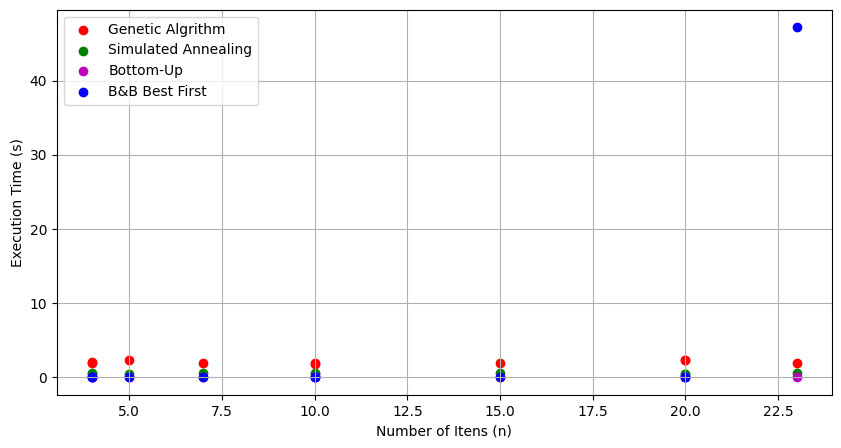

In [24]:
methods = {
    "Genetic Algrithm": knapsack_genetic,
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
n_values = []


for dataset in datasets:
    n = int(dataset[0][0])
    wmax = dataset[0][1] 
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")

    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Genetic Algrithm":
            bestValue, bestTaken = method(values, weights, wmax)  
            n_it = 0
            print("Estimated Best value:", bestValue)
        elif method_name == "Simulated Annealing":
            bestTaken, bestValue, n_it = method(values, weights, wmax)  
            print("Estimated Best value:", bestValue)
        elif method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print("Optimal value:", bestValue)
            bestTaken = None
        else:
            knapsack_solver = method(values, weights, wmax)
            bestValue, bestTaken, n_it = knapsack_solver.solve()
            print("Chosen itens:", bestTaken)

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{method_name} = {(toc - tic):.4}s")
        print(n_it, "iteraions \n")

    n_values.append(n)
    
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can again see the effect of a high knapsack capacity value impacting the data visualization.
  </p>
</div>

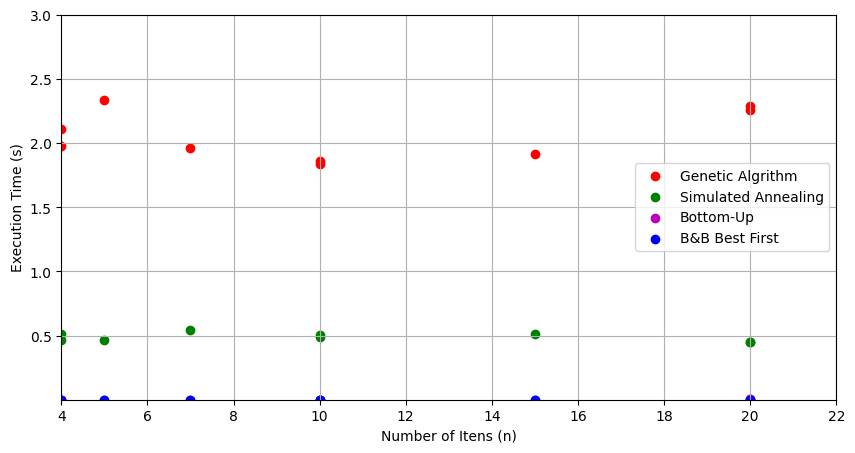

In [28]:
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlim([min(n_values), 22.0])  
plt.ylim([min(method_times), 3])  
plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The Simulated Annealing method proved to be less efficient in the Low Dimensional examples, as the number of iterations required to meet the stopping criterion is large compared to the other methods. It is also important to mention its accuracy: only one trial did not produce an estimated result equal to the optimal result (though it was still a close result), which is very good for a non-exact method.
  </p>
</div>

#### Large Scale

In [13]:
datasets = []
N_values = []
W_values = []
listing = os.listdir("./instances_01_KP/large_scale/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    print(infile)
    path = os.path.join("./instances_01_KP/large_scale/", infile)
    path = os.path.join("./instances_01_KP/large_scale/knapPI_1_200_1000_1")
    
    parts = infile.split("_")
    N = int(parts[2])  
    W = int(parts[3])  
    
    N_values.append(N)
    W_values.append(W)

    with open(path, "r") as f:
        lines = f.readlines()[:-1]  
    
    data = np.loadtxt(lines)
    datasets.append(data)
    break

knapPI_1_10000_1000_1


In [14]:
def timeout_handler(num, stack):
    raise Exception("Timeout")

methods = {
    "Genetic Algrithm": knapsack_genetic,
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

# Dic to store exec times
times = {method: [] for method in methods}
n_values = []

for dataset in datasets:
    n = dataset[0][0] 
    wmax = dataset[0][1]
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")
    
    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Genetic Algrithm":
            bestValue, bestTaken = method(values, weights, wmax)  
            print(f"{method_name}, Estimated Best value:", bestValue)
        elif method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print(f"{method_name}, Optimal value:", bestValue)
            bestTaken = None
        elif method_name == "Simulated Annealing":
            bestTaken, bestValue, n_it = method(values, weights, wmax)  
            print(f"{method_name}, Estimated Best value:", bestValue)

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{(toc - tic):.4f}s, {n_it} iterations")

    n_values.append(n)
    


=== Problem with 200 items and 1008 capacity ===
Genetic Algrithm, Estimated Best value: 0
9.3461s, 121 iterations
Simulated Annealing, Estimated Best value: 10777.0
2.9360s, 1146 iterations
Bottom-Up, Optimal value: 11238.0
0.0613s, 200 iterations


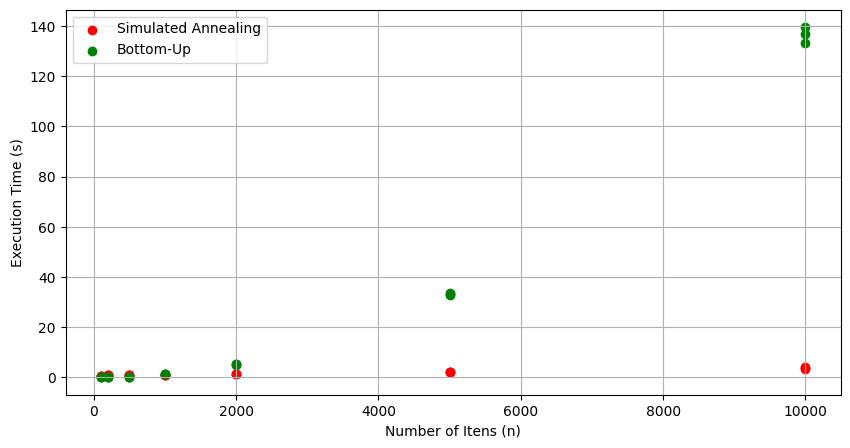

In [23]:
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For the Large Scale examples, the speed of the Simulated Annealing method was slower than the Bottom-Up method starting from 1000 items in the knapsack, as the number of iterations for BU equals the number of items, while the iterations for SA always stay within the same range. However, the estimated results were far from the optimal value, which is unsatisfactory. This may have occurred because the number of items explored is small compared to the number of available items, as the temperature drops too quickly.
  </p>
</div>